# 03. 모델 비교: 선형회귀 재평가 · 정규화 회귀(Ridge/Lasso) · 트리 계열 모델

02 노트북(`02_preprocessing_and_skew_correction.ipynb`)이 만들어 둔 전처리 개선판
데이터(Unnamed 행번호 제거 + 다중공선성 제거 + 왜도 보정)를 가지고, 아래 순서로
여러 모델의 성능을 비교합니다.

1. **01 베이스라인 재현** — 같은 `LinearRegression`/`SGDRegressor`를 새 데이터로 다시
   학습해, 전처리 개선이 실제로 성능에 도움이 됐는지 확인합니다.
2. **정규화 회귀 (Ridge / Lasso)** — 각각 어떤 원리인지 설명한 뒤, 검증(val) 성능
   기준으로 규제 강도(alpha)를 탐색합니다.
3. **트리 계열 모델 (Decision Tree / Random Forest / Gradient Boosting)** — 대표적인
   트리 계열 3종을 각각 설명한 뒤 학습·평가합니다. Random Forest는 SGD처럼 트리를
   조금씩 늘려가며 진행상황을 표시하고 체크포인트로 재개할 수 있게 만들었습니다.
4. **검증 성능 종합 비교** → **최종 테스트 평가(단 한 번만)** → **Feature Importance
   비교** → 결과 저장.

> **1차 보고서(별도 .md + .pdf)는 이 노트북을 로컬에서 실행한 뒤, 실제 결과를 가지고
> 다음 단계에서 작성합니다.** (지금은 숫자를 미리 알 수 없는 상태에서 코드만 준비합니다.)

## 참고: 01 노트북의 베이스라인 결과 (비교 기준)

| 모델 | Test R² | Test RMSE | Test MAE |
|---|---|---|---|
| SGDRegressor (01, Unnamed 컬럼 포함된 채로 학습됨) | 0.0414 | 0.0532 | 0.0334 |

이 노트북에서 다시 학습하는 모든 모델의 최종 테스트 성능을 이 값과 비교합니다.

## 프로젝트 지침 체크

- 파일 형식: `.ipynb` ✅
- 함수 설명 주석: `src/training_utils.py`에 추가한 4개 함수 모두 docstring 포함
  (`train_random_forest_with_checkpoint`, `staged_learning_curve`,
  `grid_search_by_val`, `plot_model_comparison`) ✅
- 진행상황 표시: SGDRegressor·RandomForest는 tqdm 진행률 표시줄(+체크포인트/재개),
  GradientBoosting은 학습 후 부스팅 반복별 곡선(사후 재구성), Ridge/Lasso/DecisionTree는
  하이퍼파라미터 탐색 진행률 표시줄 ✅
- 체크포인트/재개: SGDRegressor, RandomForestRegressor 모두 중단 후 이어서 학습 가능 ✅
- 데이터 누수 방지: 모든 스케일링·하이퍼파라미터 선택은 train/val만 사용, test는
  "최종 테스트 평가" 셀에서 전체 모델을 한 번에 평가할 때만 사용 ✅


In [1]:
# ===== 0. 환경 설정 =====
# - 필요한 라이브러리 불러오기 (선형/정규화 회귀, 트리 계열 모델, 스케일러 추가)
# - 경고 메시지 숨기기
# - 재현성을 위한 랜덤 시드 고정 (01/02와 동일)
# - 데이터 / 체크포인트 / 그림 저장 경로 설정
# - 한글 폰트(나눔고딕) 설정
import os
import sys
import warnings

warnings.filterwarnings(action="ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

sys.path.append(os.path.abspath(os.path.join("..", "src")))
import training_utils as tu

RANDOM_STATE = 42  # 01/02와 동일
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = os.path.join("..", "data_processed")
CHECKPOINT_DIR = os.path.join("..", "checkpoints")
FIGURE_DIR = os.path.join("..", "figures")
for d in (PROCESSED_DIR, CHECKPOINT_DIR, FIGURE_DIR):
    os.makedirs(d, exist_ok=True)

sns.set_theme(style="whitegrid")
tu.set_korean_font("NanumGothic")

print("환경 설정 완료. RANDOM_STATE =", RANDOM_STATE)


[한글 폰트] 'NanumGothicOTF' 적용 완료.
환경 설정 완료. RANDOM_STATE = 42


## 1. 02 노트북 산출물 로드

02에서 저장한 왜도 보정 완료 독립변수(`*_skew_corrected.csv`)와 종속변수(`y_*.csv`)를
불러옵니다. (컬럼 구성: Unnamed 행번호 제거 + 다중공선성 제거 + 치우친 변수만
Yeo-Johnson 변환 완료 상태. 치우치지 않았던 변수는 아직 원본 스케일 그대로입니다.)

In [2]:
# ===== 1-1. 02 산출물 로드 =====
print("02 산출물 로딩 중 ...")
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train_skew_corrected.csv"), index_col=0, encoding="utf-8-sig")
X_val = pd.read_csv(os.path.join(PROCESSED_DIR, "X_val_skew_corrected.csv"), index_col=0, encoding="utf-8-sig")
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test_skew_corrected_DO_NOT_OPEN.csv"), index_col=0, encoding="utf-8-sig")

y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv"), index_col=0, encoding="utf-8-sig").iloc[:, 0]
y_val = pd.read_csv(os.path.join(PROCESSED_DIR, "y_val.csv"), index_col=0, encoding="utf-8-sig").iloc[:, 0]
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test_DO_NOT_OPEN.csv"), index_col=0, encoding="utf-8-sig").iloc[:, 0]

print(f"  -> X_train {X_train.shape} / X_val {X_val.shape} / X_test {X_test.shape}")
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), "train/val/test 컬럼 구성이 다릅니다!"
print(f"  -> 독립변수 개수: {X_train.shape[1]}개 (컬럼 구성 일치 확인 완료)")
display(X_train.head())


02 산출물 로딩 중 ...
  -> X_train (108, 26) / X_val (14, 26) / X_test (14, 26)
  -> 독립변수 개수: 26개 (컬럼 구성 일치 확인 완료)


,건조 1존 OP_min,건조 2존 OP_min,건조로 온도 1 Zone_min,건조로 온도 2 Zone_min,세정기_min,소입2존 OP_min,소입로 CP 값_min,소입로 온도 1 Zone_min,소입로 온도 3 Zone_min,소입로 온도 4 Zone_min,...,소입1존 OP_max,소입2존 OP_max,소입3존 OP_max,소입4존 OP_max,소입로 CP 값_max,소입로 온도 1 Zone_max,소입로 온도 2 Zone_max,소입로 온도 4 Zone_max,솔트 컨베이어 온도 1 Zone_max,솔트 컨베이어 온도 2 Zone_max
87,-1.015688,-0.657428,-1.887379e-15,-2.775558e-16,0.345543,-0.181203,-1.377729,841.727,-1.665651,-4.107825e-15,...,0.096674,1.233572,1.532903,84.1172,0.586050,1.057057,3.330669e-15,1.665335e-16,1.273709,289.634
10,1.480838,0.702553,-3.330669e-16,-8.326673e-17,-1.013521,-1.432710,-0.811270,851.189,0.351584,1.110223e-15,...,0.096674,-2.131815,-1.547152,80.2534,2.152432,-0.855245,-6.772360e-15,1.110223e-16,-1.174232,290.573
134,1.115136,-2.353420,4.163336e-16,2.775558e-17,0.786573,2.201254,-1.714704,851.578,0.660215,9.992007e-16,...,0.096674,0.282017,0.345249,87.3907,-0.285515,-1.600878,-4.940492e-15,-8.326673e-17,0.253695,290.443
7,0.485137,-0.341997,-1.748601e-15,1.387779e-16,-2.500094,-1.542553,-0.689953,850.381,-1.046799,-8.604228e-15,...,0.096674,-2.019548,-1.448506,82.4366,3.566130,-0.613374,-4.607426e-15,1.387779e-16,-1.199576,289.893
135,-1.266795,-2.363734,-2.775558e-16,2.498002e-16,0.190127,0.902364,-0.697250,850.961,0.462946,-1.110223e-15,...,0.096674,0.433450,0.162156,85.6457,-0.013784,-0.461599,-5.551115e-17,-1.387779e-16,0.888489,290.486


## 2. 최종 스케일링 (모든 모델에 동일하게 적용)

02에서는 **치우친 변수만** Yeo-Johnson으로 변환했기 때문에, 지금 `X_train`에는
표준화된 변수(대략 -3~3 범위)와 원본 스케일 그대로인 변수(예: 온도 800~900대)가
섞여 있습니다. `LinearRegression`/`Ridge`/`Lasso`처럼 스케일에 민감한 모델은 이 상태로
학습하면 스케일이 큰 변수의 계수가 왜곡될 수 있어, 01과 동일하게 `MinMaxScaler`를
**train에만 fit**해서 모든 컬럼을 0~1 범위로 맞춥니다.

트리 계열 모델(Decision Tree / Random Forest / Gradient Boosting)은 각 변수를
독립적으로, 단조(monotonic) 변환에 영향받지 않는 방식으로 분기 기준을 정하기 때문에
스케일링이 성능에 영향을 주지 않습니다. 그래도 모든 모델을 **완전히 동일한 입력**으로
비교하기 위해 트리 모델에도 같은 스케일링된 데이터를 사용합니다.

In [3]:
# ===== 2-1. MinMaxScaler (train에만 fit) =====
scaler = MinMaxScaler()
scaler.fit(X_train)

feature_names = X_train.columns.tolist()
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_names, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=feature_names, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)
# X_test는 이 시점에는 transform만 해두고, 실제로 "열어보는"(평가에 사용하는) 것은
# 맨 마지막 "최종 테스트 평가" 셀에서만 한다.

joblib.dump(scaler, os.path.join(CHECKPOINT_DIR, "final_minmax_scaler.joblib"))
print("스케일링 완료. 모든 모델은 이후 X_train_scaled / X_val_scaled / X_test_scaled 를 사용합니다.")


스케일링 완료. 모든 모델은 이후 X_train_scaled / X_val_scaled / X_test_scaled 를 사용합니다.


## 3. 01 베이스라인 재현: LinearRegression + SGDRegressor (새 전처리 데이터로)

In [4]:
# ===== 3-1. LinearRegression (closed-form) =====
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("LinearRegression 학습 완료")

lr_train_metrics = tu.evaluate_regression(y_train, lr_model.predict(X_train_scaled))
lr_val_metrics = tu.evaluate_regression(y_val, lr_model.predict(X_val_scaled))
print("train:", lr_train_metrics)
print("val  :", lr_val_metrics)


LinearRegression 학습 완료
train: {'R2': 0.23749423254510582, 'RMSE': 0.04298776909871807, 'MAE': 0.02787536162251354}
val  : {'R2': -0.08552165592148997, 'RMSE': 0.028021382423062083, 'MAE': 0.02379822794345474}


In [5]:
# ===== 3-2. SGDRegressor (진행상황 표시 + 체크포인트 재개) =====
# 01과 동일한 로직이지만, 새 전처리 데이터를 사용하므로 체크포인트 파일명을 다르게 두어
# 01의 체크포인트(sgd_baseline.joblib)를 건드리지 않는다.
sgd_ckpt_mgr = tu.CheckpointManager(CHECKPOINT_DIR, name="sgd_v2_skewcorrected")

sgd_result = tu.train_sgd_regressor_with_checkpoint(
    X_train_scaled.values, y_train.values,
    X_val_scaled.values, y_val.values,
    checkpoint_mgr=sgd_ckpt_mgr,
    n_epochs=300, checkpoint_every=10, patience=40,
    random_state=RANDOM_STATE, resume=True,
)
sgd_model = sgd_result["model"]
sgd_history = sgd_result["history"]

fig = tu.plot_training_curve(sgd_history, title="SGDRegressor 학습 곡선 (전처리 개선판 데이터)")
fig.savefig(os.path.join(FIGURE_DIR, "13_sgd_v2_training_curve.png"), dpi=150)
plt.show()

sgd_train_metrics = tu.evaluate_regression(y_train, sgd_model.predict(X_train_scaled))
sgd_val_metrics = tu.evaluate_regression(y_val, sgd_model.predict(X_val_scaled))
print("train:", sgd_train_metrics)
print("val  :", sgd_val_metrics)


[체크포인트 발견] epoch 51 부터 이어서 학습을 재개합니다. (기존 best_val_loss=0.0007)


SGD 학습 진행:   0%|          | 0/249 [00:00<?, ?epoch/s]


[조기 종료] epoch 90 : 검증 손실이 40회 연속 개선되지 않아 학습을 종료합니다.


<Figure size 800x500 with 1 Axes>

train: {'R2': 0.03260381507647503, 'RMSE': 0.048420082622274964, 'MAE': 0.028115111877784944}
val  : {'R2': 0.06037078927396089, 'RMSE': 0.02607045230521391, 'MAE': 0.01949952195580029}


## 4. 정규화 회귀: Ridge / Lasso

**Ridge(L2 규제)**: 회귀계수 제곱합에 페널티를 줘서 계수들을 전반적으로 작게(0에
가깝게) 유지한다. 다중공선성이 남아있거나 변수 수가 표본 수에 비해 많을 때
(지금 136개 표본에 20여개 변수) 분산을 줄여 과적합을 완화하는 데 효과적이다.

**Lasso(L1 규제)**: 회귀계수 절댓값 합에 페널티를 줘서, 규제가 강해지면 일부 계수를
**정확히 0으로** 만든다. 즉 자동으로 변수 선택(feature selection)이 일어난다는 점이
Ridge와의 핵심 차이다.

두 모델 모두 규제 강도를 결정하는 `alpha`가 핵심 하이퍼파라미터라, `grid_search_by_val()`
로 여러 alpha 후보를 val 성능 기준으로 탐색한다 (test는 사용하지 않음).

In [6]:
# ===== 4-1. Ridge: alpha 탐색 =====
ridge_grid = [{"alpha": a} for a in np.logspace(-3, 3, 13)]  # 0.001 ~ 1000
ridge_search = tu.grid_search_by_val(Ridge, ridge_grid, X_train_scaled, y_train, X_val_scaled, y_val,
                                      random_state=RANDOM_STATE)
ridge_model = ridge_search["best_model"]
print("Ridge 최적 alpha:", ridge_search["best_params"])
display(ridge_search["results"])


Ridge 하이퍼파라미터 탐색:   0%|          | 0/13 [00:00<?, ?it/s]

Ridge 최적 alpha: {'alpha': 31.622776601683793}


,alpha,train_R2,val_R2,val_RMSE,val_MAE
0,31.622777,0.039674,0.012421,0.026727,0.020060
1,10.000000,0.085732,0.010696,0.026751,0.019824
2,100.000000,0.015470,0.005627,0.026819,0.020323
3,316.227766,0.005333,0.001124,0.026880,0.020452
4,1000.000000,0.001738,-0.000730,0.026905,0.020499
5,3.162278,0.157193,-0.056022,0.027638,0.020078
6,1.000000,0.236209,-0.282657,0.030460,0.024400
7,0.316228,0.289516,-0.544133,0.033420,0.028160
8,0.100000,0.310681,-0.670053,0.034756,0.029633
9,0.001000,0.316843,-0.691396,0.034978,0.029867


In [7]:
# ===== 4-2. Lasso: alpha 탐색 =====
# Lasso는 좌표하강법(coordinate descent)으로 최적화되며 alpha가 작을수록 수렴에
# 반복이 더 필요할 수 있어 max_iter를 넉넉히 준다.
lasso_grid = [{"alpha": a} for a in np.logspace(-4, 1, 13)]  # 0.0001 ~ 10
lasso_search = tu.grid_search_by_val(Lasso, lasso_grid, X_train_scaled, y_train, X_val_scaled, y_val,
                                      fixed_params={"max_iter": 20000}, random_state=RANDOM_STATE)
lasso_model = lasso_search["best_model"]
print("Lasso 최적 alpha:", lasso_search["best_params"])
display(lasso_search["results"])

n_zero_coef = int((np.abs(lasso_model.coef_) < 1e-10).sum())
print(f"\nLasso가 0으로 만든(자동 제외한) 변수 개수: {n_zero_coef} / {len(feature_names)}")


Lasso 하이퍼파라미터 탐색:   0%|          | 0/13 [00:00<?, ?it/s]

Lasso 최적 alpha: {'alpha': 0.0006812920690579615}


,alpha,train_R2,val_R2,val_RMSE,val_MAE
0,0.000681,0.119494,0.059459,0.026083,0.018114
1,0.004642,0.000000,-0.001677,0.026917,0.020523
2,0.012115,0.000000,-0.001677,0.026917,0.020523
3,0.031623,0.000000,-0.001677,0.026917,0.020523
4,0.082540,0.000000,-0.001677,0.026917,0.020523
5,0.215443,0.000000,-0.001677,0.026917,0.020523
6,0.562341,0.000000,-0.001677,0.026917,0.020523
7,1.467799,0.000000,-0.001677,0.026917,0.020523
8,3.831187,0.000000,-0.001677,0.026917,0.020523
9,10.000000,0.000000,-0.001677,0.026917,0.020523



Lasso가 0으로 만든(자동 제외한) 변수 개수: 19 / 26


## 5. 트리 계열 모델: Decision Tree / Random Forest / Gradient Boosting

**Decision Tree(의사결정나무)**: 변수 하나씩 기준값으로 데이터를 반복 분할해 나가는
가장 단순한 트리 모델. 해석이 쉽지만 트리가 깊어질수록 훈련 데이터에 과적합되기
쉽다 (특히 표본이 136개뿐인 이 데이터에서는 더 그렇다). `max_depth`(트리 최대 깊이)를
val 성능 기준으로 탐색해 과적합을 억제한다.

**Random Forest(랜덤포레스트)**: 서로 다른 표본/변수 부분집합으로 학습한 여러 개의
Decision Tree를 앙상블(평균)한다. 트리 하나하나는 과적합되더라도 여러 트리를 평균 내면
분산이 줄어 Decision Tree 단독보다 일반적으로 더 안정적이다. `warm_start`로 트리를
조금씩 늘려가며(SGD의 epoch처럼) 검증 성능을 추적하고, 중간에 끊겨도 이어서 트리를
추가할 수 있게 구현했다 (`train_random_forest_with_checkpoint`).

**Gradient Boosting(그래디언트 부스팅)**: 이전 트리들이 만든 오차(잔차)를 다음 트리가
순차적으로 줄여나가는 방식. 트리를 병렬로 독립 학습하는 Random Forest와 달리 순서대로
학습하며, 보통 세 모델 중 성능이 가장 좋은 경우가 많지만 학습률/트리 개수 설정에 따라
과적합에 민감하다. `staged_predict()`로 부스팅 반복마다의 학습 곡선을 사후에 재구성해
검증 성능이 가장 좋았던 반복 수(`best_n_estimators`)를 찾고, 그 개수로 다시 학습한다.

In [8]:
# ===== 5-1. Decision Tree: max_depth 탐색 =====
dt_grid = [{"max_depth": d} for d in [2, 3, 4, 5, 6, 8, None]]
dt_search = tu.grid_search_by_val(DecisionTreeRegressor, dt_grid, X_train_scaled, y_train, X_val_scaled, y_val,
                                   random_state=RANDOM_STATE)
dt_model = dt_search["best_model"]
print("DecisionTree 최적 max_depth:", dt_search["best_params"])
display(dt_search["results"])


DecisionTreeRegressor 하이퍼파라미터 탐색:   0%|          | 0/7 [00:00<?, ?it/s]

DecisionTree 최적 max_depth: {'max_depth': 4}


,max_depth,train_R2,val_R2,val_RMSE,val_MAE
0,4.0,0.835311,0.054596,0.026150,0.018415
1,2.0,0.503357,-0.312463,0.030812,0.022400
2,3.0,0.647766,-0.350154,0.031251,0.022171
3,6.0,0.898780,-0.564163,0.033637,0.025659
4,5.0,0.878222,-5.419630,0.068144,0.038262
5,8.0,0.929812,-5.564466,0.068908,0.039266
6,NaN,1.000000,-5.565451,0.068913,0.041446


[체크포인트 발견] step 10 (트리 200개)부터 이어서 학습을 재개합니다. (기존 best_val_loss=0.0010)


RandomForest 학습 진행 (트리 추가):   0%|          | 0/5 [00:00<?, ?step/s]


[조기 종료] step 14 (트리 300개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


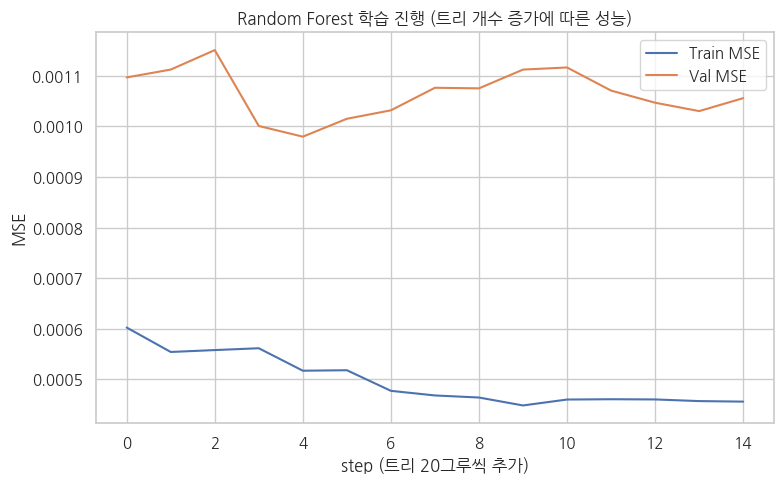

최종 트리 개수: 100


In [9]:
# ===== 5-2. Random Forest: 진행상황 표시 + 체크포인트 재개 =====
rf_ckpt_mgr = tu.CheckpointManager(CHECKPOINT_DIR, name="random_forest")

rf_result = tu.train_random_forest_with_checkpoint(
    X_train_scaled, y_train, X_val_scaled, y_val,
    checkpoint_mgr=rf_ckpt_mgr,
    max_estimators=300, estimators_per_step=20,
    checkpoint_every_steps=3, patience_steps=5,
    random_state=RANDOM_STATE, resume=True,
    max_depth=None,
)
rf_model = rf_result["model"]
rf_history = rf_result["history"]

fig = tu.plot_training_curve(rf_history, title="Random Forest 학습 진행 (트리 개수 증가에 따른 성능)",
                              xlabel="step (트리 20그루씩 추가)")
fig.savefig(os.path.join(FIGURE_DIR, "14_random_forest_training_curve.png"), dpi=150)
plt.show()

print(f"최종 트리 개수: {rf_model.n_estimators}")


GradientBoosting 학습 중 (n_estimators=300) ...
  -> 학습 완료. staged_predict()로 부스팅 반복별 성능을 재구성합니다.


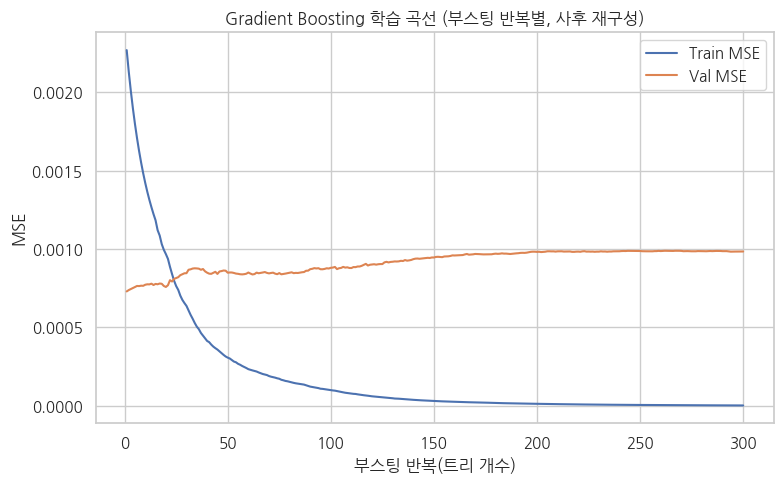

검증 손실이 가장 낮았던 반복 수: 1 / 300
GradientBoosting 최종 모델 학습 완료 (n_estimators=1)


In [10]:
# ===== 5-3. Gradient Boosting: 학습 후 부스팅 반복별 곡선으로 최적 반복 수 탐색 =====
gb_full = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
)
print("GradientBoosting 학습 중 (n_estimators=300) ...")
gb_full.fit(X_train_scaled, y_train)
print("  -> 학습 완료. staged_predict()로 부스팅 반복별 성능을 재구성합니다.")

gb_history = tu.staged_learning_curve(gb_full, X_train_scaled, y_train, X_val_scaled, y_val)
fig = tu.plot_training_curve(gb_history, title="Gradient Boosting 학습 곡선 (부스팅 반복별, 사후 재구성)",
                              xlabel="부스팅 반복(트리 개수)")
fig.savefig(os.path.join(FIGURE_DIR, "15_gradient_boosting_training_curve.png"), dpi=150)
plt.show()

best_n_estimators = int(gb_history["val_mse"].idxmin() + 1)
print(f"검증 손실이 가장 낮았던 반복 수: {best_n_estimators} / 300")

# 최적 반복 수로 다시 학습 (조기 종료를 실제로 적용한 최종 모델)
gb_model = GradientBoostingRegressor(
    n_estimators=best_n_estimators, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
)
gb_model.fit(X_train_scaled, y_train)
print(f"GradientBoosting 최종 모델 학습 완료 (n_estimators={best_n_estimators})")


## 6. 검증(val) 성능 종합 비교

,model,split,R2,RMSE,MAE
0,LinearRegression,train,0.237494,0.042988,0.027875
1,LinearRegression,val,-0.085522,0.028021,0.023798
2,SGDRegressor,train,0.032604,0.048420,0.028115
3,SGDRegressor,val,0.060371,0.026070,0.019500
4,Ridge,train,0.039674,0.048243,0.027681
5,Ridge,val,0.012421,0.026727,0.020060
6,Lasso,train,0.119494,0.046194,0.026860
7,Lasso,val,0.059459,0.026083,0.018114
8,DecisionTree,train,0.835311,0.019978,0.015065
9,DecisionTree,val,0.054596,0.026150,0.018415


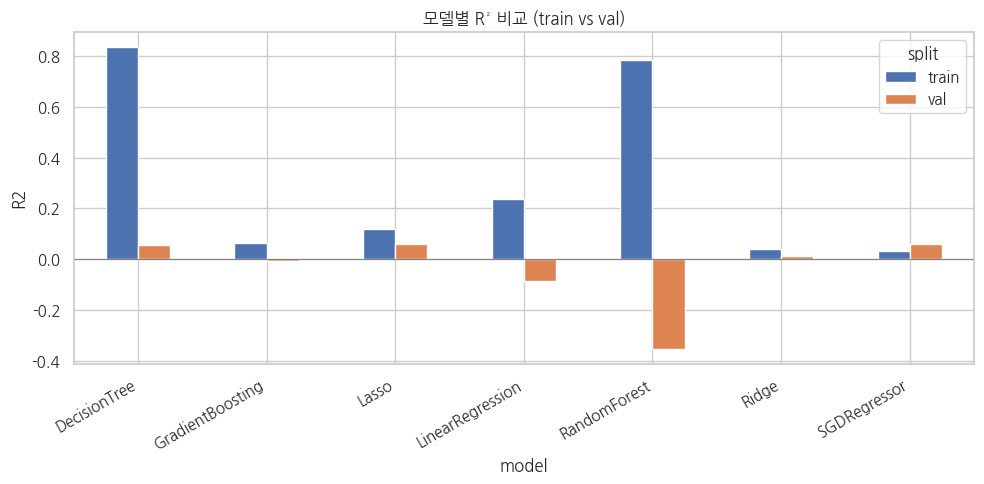


=== 검증(val) R² 기준 순위 ===


,model,R2,RMSE,MAE
0,SGDRegressor,0.060371,0.026070,0.019500
1,Lasso,0.059459,0.026083,0.018114
2,DecisionTree,0.054596,0.026150,0.018415
3,Ridge,0.012421,0.026727,0.020060
4,GradientBoosting,-0.008840,0.027014,0.020544
5,LinearRegression,-0.085522,0.028021,0.023798
6,RandomForest,-0.354402,0.031300,0.024186


In [11]:
# ===== 6-1. 모든 모델의 train/val 지표 모으기 =====
models = {
    "LinearRegression": lr_model,
    "SGDRegressor": sgd_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "DecisionTree": dt_model,
    "RandomForest": rf_model,
    "GradientBoosting": gb_model,
}

rows = []
for name, model in models.items():
    train_metrics = tu.evaluate_regression(y_train, model.predict(X_train_scaled))
    val_metrics = tu.evaluate_regression(y_val, model.predict(X_val_scaled))
    rows.append({"model": name, "split": "train", **train_metrics})
    rows.append({"model": name, "split": "val", **val_metrics})

val_metrics_df = pd.DataFrame(rows)
display(val_metrics_df)

fig = tu.plot_model_comparison(val_metrics_df, metric="R2", title="모델별 R² 비교 (train vs val)")
fig.savefig(os.path.join(FIGURE_DIR, "16_model_comparison_val_r2.png"), dpi=150)
plt.show()

# val R2 기준 순위
val_ranking = (
    val_metrics_df[val_metrics_df["split"] == "val"]
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
print("\n=== 검증(val) R² 기준 순위 ===")
display(val_ranking[["model", "R2", "RMSE", "MAE"]])


## 7. Feature Importance 비교

선형 계열 모델(LinearRegression/Ridge/Lasso)의 **회귀계수**와, 트리 계열 모델의
**feature_importances_**(분할에 얼마나 기여했는지)를 나란히 비교한다. 트리 모델의
중요도는 항상 0 이상의 값이라 `plot_feature_importance()`의 빨강/파랑 색 구분(계수
부호)이 트리 모델에는 의미가 없다는 점만 참고할 것.

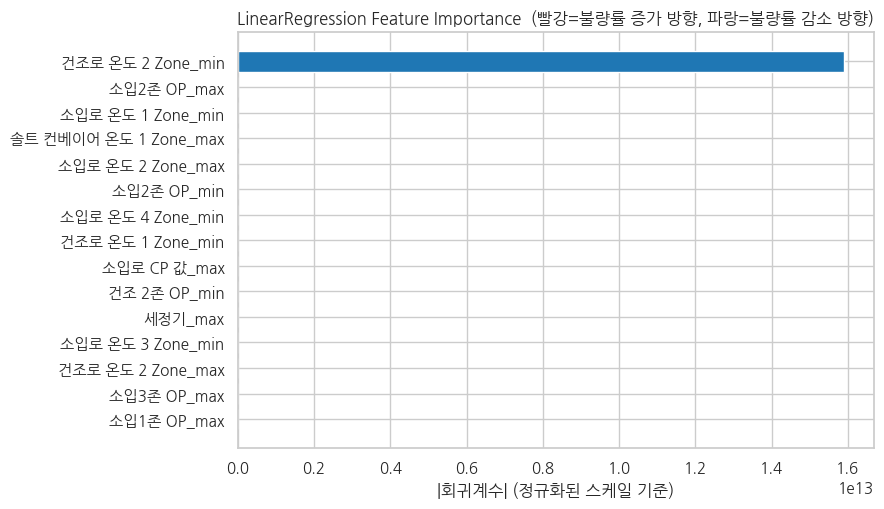

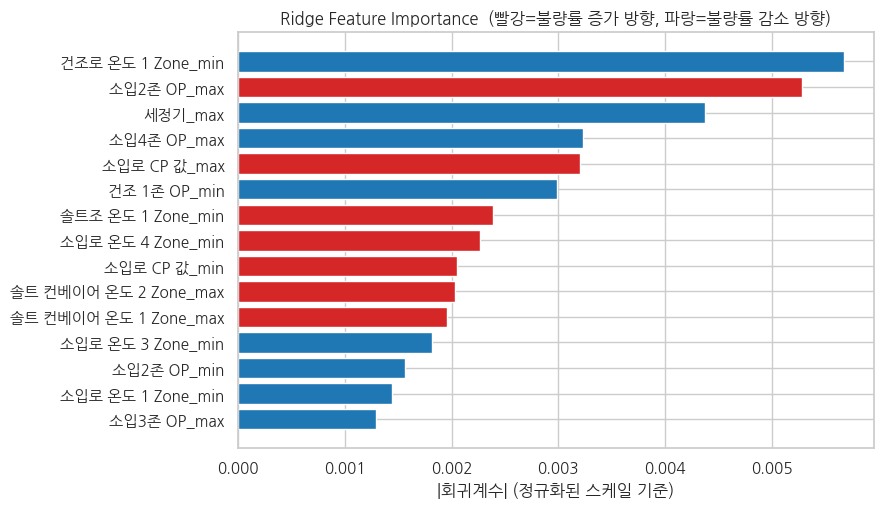

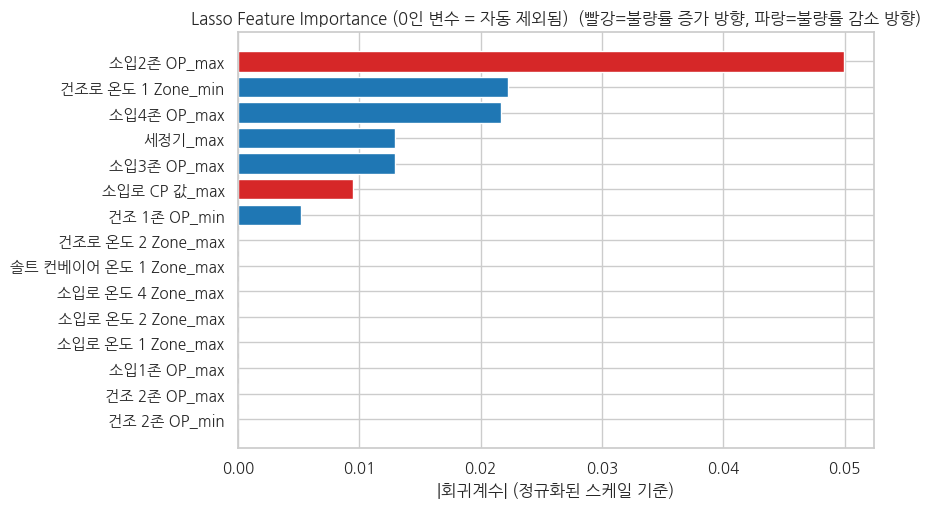

In [12]:
# ===== 7-1. 선형 계열: 회귀계수 기반 =====
fig = tu.plot_feature_importance(feature_names, lr_model.coef_, top_n=15,
                                  title="LinearRegression Feature Importance")
fig.savefig(os.path.join(FIGURE_DIR, "17_feature_importance_linear.png"), dpi=150)
plt.show()

fig = tu.plot_feature_importance(feature_names, ridge_model.coef_, top_n=15,
                                  title="Ridge Feature Importance")
plt.show()

fig = tu.plot_feature_importance(feature_names, lasso_model.coef_, top_n=15,
                                  title="Lasso Feature Importance (0인 변수 = 자동 제외됨)")
plt.show()


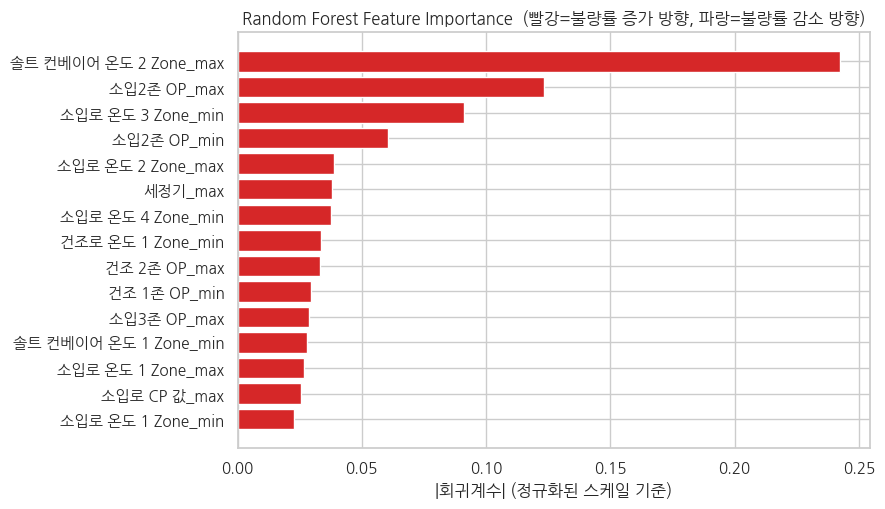

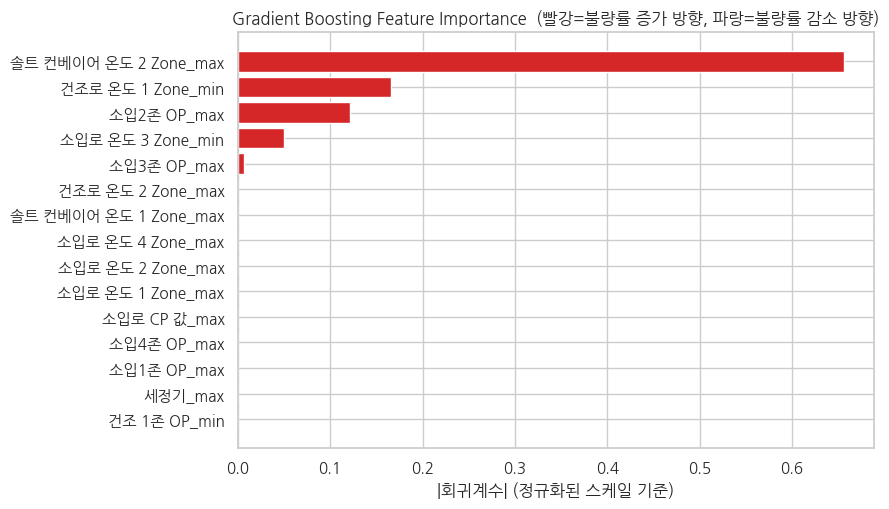

In [13]:
# ===== 7-2. 트리 계열: feature_importances_ 기반 =====
fig = tu.plot_feature_importance(feature_names, rf_model.feature_importances_, top_n=15,
                                  title="Random Forest Feature Importance")
fig.savefig(os.path.join(FIGURE_DIR, "18_feature_importance_tree.png"), dpi=150)
plt.show()

fig = tu.plot_feature_importance(feature_names, gb_model.feature_importances_, top_n=15,
                                  title="Gradient Boosting Feature Importance")
plt.show()


## 8. 최종 테스트 평가 (이 노트북에서 Test를 여는 유일한 셀)

여기까지 어떤 모델 선택·하이퍼파라미터 탐색에도 `X_test`, `y_test`를 사용하지
않았다. 아래 셀에서 **처음이자 마지막으로** 모든 모델을 test 세트로 한 번에
평가한다. (개별 모델을 보고 다시 튜닝하지 않는다 — 그러면 test가 검증셋처럼
되어버려 의미가 없어진다.)

=== 최종 Test 성능 (R² 기준 내림차순) ===


,model,split,R2,RMSE,MAE
0,Lasso,test,0.118647,0.051039,0.032820
1,Ridge,test,0.036803,0.053356,0.033297
2,SGDRegressor,test,0.030485,0.053531,0.033224
3,LinearRegression,test,0.003645,0.054267,0.034597
4,GradientBoosting,test,-0.001445,0.054405,0.033265
5,DecisionTree,test,-0.132925,0.057867,0.034362
6,RandomForest,test,-0.315009,0.062344,0.041341


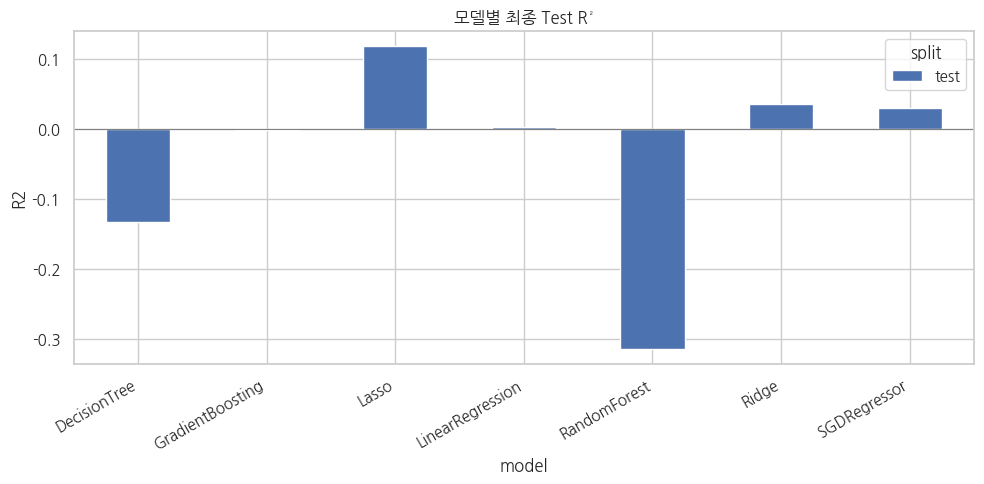


최종 선정 모델: Lasso  (Test R2 = 0.1186)
참고: 01 베이스라인(SGDRegressor, Unnamed 포함) Test R2 = 0.0414


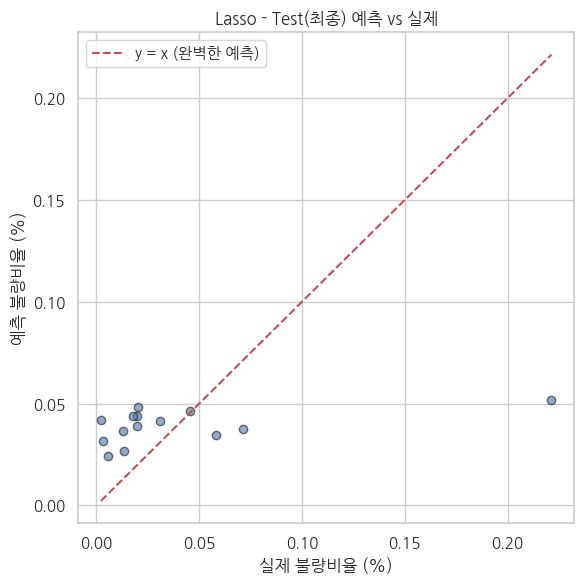

In [14]:
# ===== 최종 테스트 평가 =====
test_rows = []
for name, model in models.items():
    test_metrics = tu.evaluate_regression(y_test, model.predict(X_test_scaled))
    test_rows.append({"model": name, "split": "test", **test_metrics})

test_metrics_df = pd.DataFrame(test_rows).sort_values("R2", ascending=False).reset_index(drop=True)
print("=== 최종 Test 성능 (R² 기준 내림차순) ===")
display(test_metrics_df)

fig = tu.plot_model_comparison(test_metrics_df, metric="R2", title="모델별 최종 Test R²")
fig.savefig(os.path.join(FIGURE_DIR, "19_model_comparison_test_r2.png"), dpi=150)
plt.show()

best_model_name = test_metrics_df.iloc[0]["model"]
best_test_r2 = test_metrics_df.iloc[0]["R2"]
print(f"\n최종 선정 모델: {best_model_name}  (Test R2 = {best_test_r2:.4f})")
print(f"참고: 01 베이스라인(SGDRegressor, Unnamed 포함) Test R2 = 0.0414")

fig = tu.plot_pred_vs_actual(y_test.values, models[best_model_name].predict(X_test_scaled),
                              title=f"{best_model_name} - Test(최종) 예측 vs 실제")
fig.savefig(os.path.join(FIGURE_DIR, "20_best_model_test_pred_vs_actual.png"), dpi=150)
plt.show()


## 9. 결과 저장

In [15]:
# ===== 9-1. 모델 / 지표 / 그림 저장 =====
print("결과 저장 중 ...")

model_files = {
    "linear_regression": lr_model,
    "ridge": ridge_model,
    "lasso": lasso_model,
    "decision_tree": dt_model,
    "gradient_boosting": gb_model,
    # sgd_model, rf_model 은 각각 체크포인트 매니저가 이미 저장해 두었음
    # (checkpoints/sgd_v2_skewcorrected.joblib, checkpoints/random_forest.joblib)
}
for name, model in model_files.items():
    path = os.path.join(CHECKPOINT_DIR, f"{name}.joblib")
    joblib.dump(model, path)
print(f"  -> 모델 {len(model_files)}개 + SGD/RandomForest 체크포인트 저장 완료 (checkpoints/)")

val_metrics_df.to_csv(os.path.join(PROCESSED_DIR, "model_comparison_val_metrics.csv"),
                       index=False, encoding="utf-8-sig")
test_metrics_df.to_csv(os.path.join(PROCESSED_DIR, "model_comparison_test_metrics.csv"),
                        index=False, encoding="utf-8-sig")
print("  -> 모델 비교 지표 저장 완료 (data_processed/model_comparison_val_metrics.csv, "
      "model_comparison_test_metrics.csv)")

hyperparam_summary = pd.DataFrame([
    {"model": "Ridge", "best_params": ridge_search["best_params"]},
    {"model": "Lasso", "best_params": lasso_search["best_params"]},
    {"model": "DecisionTree", "best_params": dt_search["best_params"]},
    {"model": "RandomForest", "best_params": {"n_estimators": rf_model.n_estimators}},
    {"model": "GradientBoosting", "best_params": {"n_estimators": best_n_estimators}},
])
hyperparam_summary.to_csv(os.path.join(PROCESSED_DIR, "model_comparison_best_hyperparams.csv"),
                           index=False, encoding="utf-8-sig")
print("  -> 최적 하이퍼파라미터 요약 저장 완료 (data_processed/model_comparison_best_hyperparams.csv)")

print(f"\n최종 선정 모델: {best_model_name} (Test R2 = {best_test_r2:.4f})")
print("모든 산출물 저장 완료.")


결과 저장 중 ...
  -> 모델 5개 + SGD/RandomForest 체크포인트 저장 완료 (checkpoints/)
  -> 모델 비교 지표 저장 완료 (data_processed/model_comparison_val_metrics.csv, model_comparison_test_metrics.csv)
  -> 최적 하이퍼파라미터 요약 저장 완료 (data_processed/model_comparison_best_hyperparams.csv)

최종 선정 모델: Lasso (Test R2 = 0.1186)
모든 산출물 저장 완료.


## 10. 결론 및 다음 단계

- 이 셀들을 로컬에서 순서대로 실행하면, `data_processed/model_comparison_val_metrics.csv`,
  `model_comparison_test_metrics.csv`, `model_comparison_best_hyperparams.csv`와
  `figures/13_~20_*.png`(총 8장), `checkpoints/`의 모델 7종이 모두 생성됩니다.
- **다음 단계**: 이 결과들을 가지고 1차 보고서(`reports/` 폴더에 `.md` + `.pdf`)를
  작성합니다. 어떤 모델이 최종적으로 선택됐는지, 01 대비 성능이 얼마나 개선됐는지(혹은
  개선되지 않았는지와 그 이유), 변수 중요도 해석, 표본 수(136개)의 근본적인 한계와
  향후 개선 아이디어(추가 파생변수, K-Fold 교차검증, XGBoost/LightGBM 등)를 정리할
  예정입니다.
